In [2]:
import scipy.io
import pandas as pd
import numpy as np
from tqdm import tqdm
from utils.dynamicRieszFunctions import *
import joblib
import pickle
river_data = pd.read_csv("data/river_data.csv") # experimental
other_data = pd.read_csv("data/others_data.csv") # observational
# Define pretreatment variables
pretreat_vars = (
    [f"paid{i}" for i in range(1, 5)] +         # 4 lagged values for aid
    [f"tcpp{i}" for i in range(1, 11)] +        # 10 lagged values for employment
    [f"tcprn{i}" for i in range(1, 11)]         # 10 lagged values for earnings
)
def difference_of_means(treated,  control):

    treated = np.asarray(treated)
    control = np.asarray(control)

    n_t = len(treated)
    n_c = len(control)

    mean_t = np.mean(treated)
    mean_c = np.mean(control)

    var_t = np.var(treated)  # sample variance
    var_c = np.var(control)

    diff = mean_t - mean_c
    se = np.sqrt(var_t / n_t + var_c / n_c)

    return diff, se
def ci(point, sigma):
    ub = point + 1.96 * sigma
    lb = point - 1.96 * sigma 
    return ub, lb
# List of used covariates
covariates = [
    "xsexf", "xhsdip", "xchld05", "single",
    "grd1720", "grade16", "grd1315", "grade12", "grde911", "white",
    "hisp", "black", "age"
] + pretreat_vars
def create_dataset(quarters, application):
    if application not in ["earn", "employ"]:
        raise ValueError
    Y_obsorved = other_data[f"Y_{application}"]
    Y_experimental = river_data[f"Y_{application}"] # not used in fitting, only to evaluate
    if application == "employ":
        s_colums = (
            [f"{application}{i}" for i in range(1, quarters+ 1)] +
            [f"aid{i}" for i in range(1, quarters+ 1)] +
            [f"earn{i}" for i in range(1, quarters + 1)]
        )
    elif application == "earn":
        s_colums = (
            [f"{application}{i}" for i in range(1, quarters+ 1)] +
            [f"aid{i}" for i in range(1, quarters + 1)]
        )

    S_obs = other_data[s_colums]
    S_exp = river_data[s_colums]
    D_exp = river_data["e"]
    D_obs = other_data["e"]
    X_obs = other_data[covariates]
    X_exp = river_data[covariates]
    Y_all = pd.concat([Y_obsorved, Y_experimental], axis=0).reset_index(drop=True)
    X_all = pd.concat([X_obs, X_exp], axis=0).reset_index(drop=True)
    S_all = pd.concat([S_obs, S_exp], axis=0).reset_index(drop=True)
    D_all = pd.concat([D_obs, D_exp], axis=0).reset_index(drop=True)
    G_all = pd.concat([
        pd.Series(np.ones(len(D_obs))),
        pd.Series(np.zeros(len(D_exp)))
    ], axis=0).reset_index(drop=True)

    Y_all_torch = torch.tensor(Y_all.values, dtype=torch.float64).view(-1, 1)
    X_all_torch = torch.tensor(X_all.values, dtype=torch.float64)
    S_all_torch = torch.tensor(S_all.values, dtype=torch.float64)
    D_all_torch = torch.tensor(D_all.values, dtype=torch.float64).view(-1, 1)
    G_all_torch = torch.tensor(G_all.values, dtype=torch.float64).view(-1, 1)
    return {"Y_obsorved": Y_obsorved,"Y_experimental": Y_experimental, "S_obs": S_obs, "S_exp":S_exp,
            "D_exp": D_exp, "D_ops":D_obs, "X_obs": X_obs, "X_exp": X_exp, "Y_all" : Y_all_torch, "X_all": X_all_torch, "S_all": S_all_torch, "D_all": D_all_torch, "G_all": G_all_torch,
            "names_x":covariates, "names_z":s_colums }
ds =create_dataset(6,"earn")

In [3]:
Y_exp= ds["Y_experimental"]
D_exp = ds["D_exp"]
true_effect, true_sd  =difference_of_means(Y_exp[D_exp == 1], Y_exp[D_exp ==0])
print(true_effect, f"({true_sd})")

249.0544297398368 (51.038236817705666)


In [4]:
n = ds["S_all"].shape[0]

In [5]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [6]:
import re
import numpy as np
import matplotlib.pyplot as plt

def plot_estimators(atts_athey, stds_athey, ATT, robust_bounds, caption,
                    exclude_last=0, extra_estimators=None):

    def ci(estimates, stds, z=1.96):
        upper = estimates + z * stds
        lower = estimates - z * stds
        return upper, lower

    # Compute bounds for main estimators
    athey_bounds = ci(atts_athey, stds_athey)
    benchmark_bounds = ci(true_effect, true_sd)

    # Combine all estimates
    all_estimates = np.concatenate(([true_effect], atts_athey, ATT))
    all_upper = np.concatenate(([benchmark_bounds[0]], athey_bounds[0], np.squeeze(robust_bounds[0])))
    all_lower = np.concatenate(([benchmark_bounds[1]], athey_bounds[1], np.squeeze(robust_bounds[1])))

    labels = [
        "Benchmark", 
        "Naive", 
        "Surrogacy Index", 
        "Surrogacy Score", 
        "Influence Function", 
        "LASSO", 
        "RF", 
        "Net"
    ]

   

    # Start plot
    plt.figure(figsize=(15, 5))
    plt.errorbar(
        x=labels, y=all_estimates,
        yerr=[all_estimates - all_lower, all_upper - all_estimates],
        fmt='o', capsize=5, color='blue', ecolor='gray', elinewidth=2
    )

    # Optionally add extra estimators
    if extra_estimators is not None and len(extra_estimators) > 0:
        extra_labels = list(extra_estimators.keys())
        extra_means = np.array([v[0] for v in extra_estimators.values()])
        extra_bounds = np.array([v[2] for v in extra_estimators.values()])
        extra_lower = extra_bounds[:, 0]
        extra_upper = extra_bounds[:, 1]

        if exclude_last > 0:
            extra_labels = extra_labels[:-exclude_last]
            extra_means = extra_means[:-exclude_last]
            extra_lower = extra_lower[:-exclude_last]
            extra_upper = extra_upper[:-exclude_last]

        plt.errorbar(
            x=extra_labels, y=extra_means,
            yerr=[extra_means - extra_lower, extra_upper - extra_means],
            fmt='o', capsize=5, color='red', ecolor='gray', elinewidth=2
        )

        labels = labels + extra_labels  # optional if you need combined tick control

    plt.ylabel('Point Estimate')
    plt.title(caption)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()


estimates = pd.read_csv("application_results_final/q6.csv")
atts_athey_6= np.array([327.1, 238.8,  279.7,  280.6])
stds_athey_6  =np.array( [36.6, 31.5, 32.5, 32.9])

ATT_6  = [float(re.search(r"tensor\(([-\d\.]+)", s).group(1)) for s in estimates.iloc[:, ::2].values.flatten()]

std_6 = [float(re.search(r"tensor\(([-\d\.]+)", s).group(1)) for s in estimates.iloc[:, 1::2].values.flatten()]

robust_bounds = ci(ATT_6, std_6/np.sqrt(n))


In [7]:
ATT_6

[203.8262, 240.6666, 263.7033]

In [8]:
with open("../NNIPV/results_nnpiv_earnings.pkl", "rb") as f:
    results = pickle.load(f)

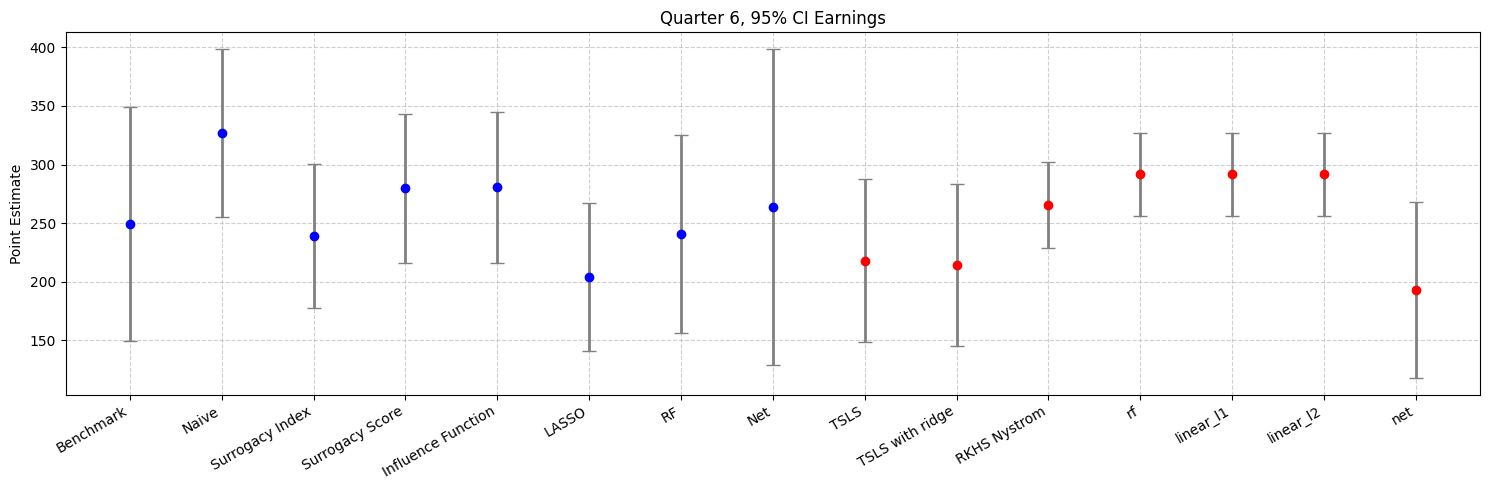

In [9]:
plot_estimators(atts_athey_6,stds_athey_6, ATT_6, robust_bounds, "Quarter 6, 95% CI Earnings", extra_estimators=results)

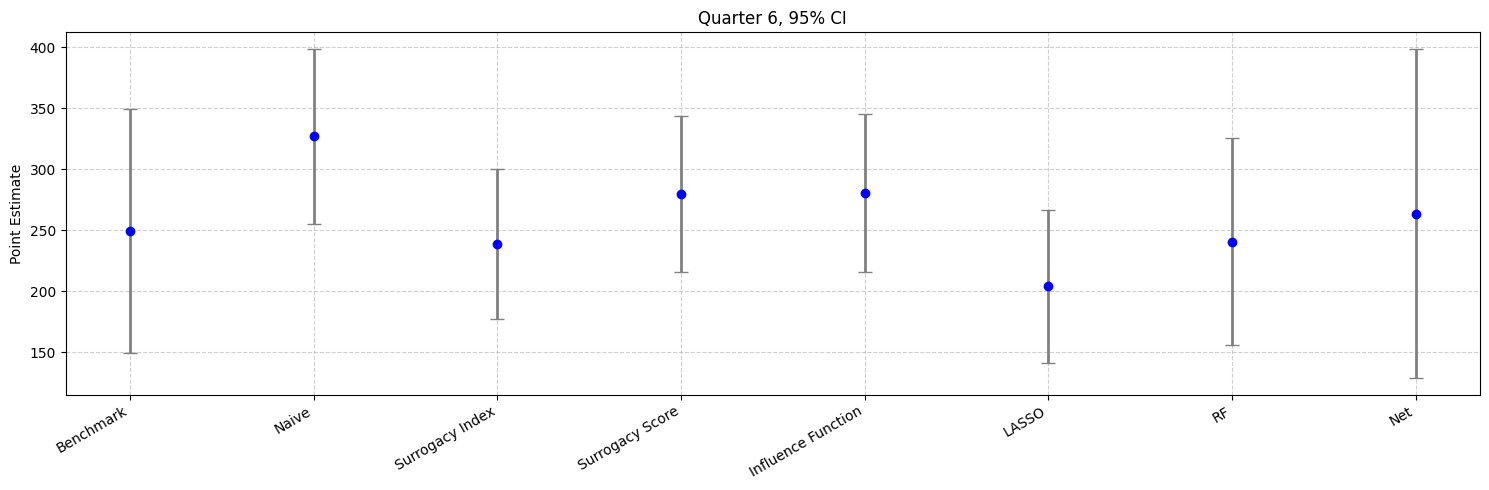

In [10]:
plot_estimators(atts_athey_6,stds_athey_6, ATT_6, robust_bounds, "Quarter 6, 95% CI",2)

## q 5

In [9]:
estimates = pd.read_csv("application_results_final/q5.csv")


ATT_5 = [float(re.search(r"tensor\(([-\d\.]+)", s).group(1)) for s in estimates.iloc[:, ::2].values.flatten()]

std_5 = [float(re.search(r"tensor\(([-\d\.]+)", s).group(1)) for s in estimates.iloc[:, 1::2].values.flatten()]


In [10]:
ATT_5

[196.9109, 193.9707, 222.833]

In [11]:
std_5

[4027.2623, 6351.4308, 9539.9452]

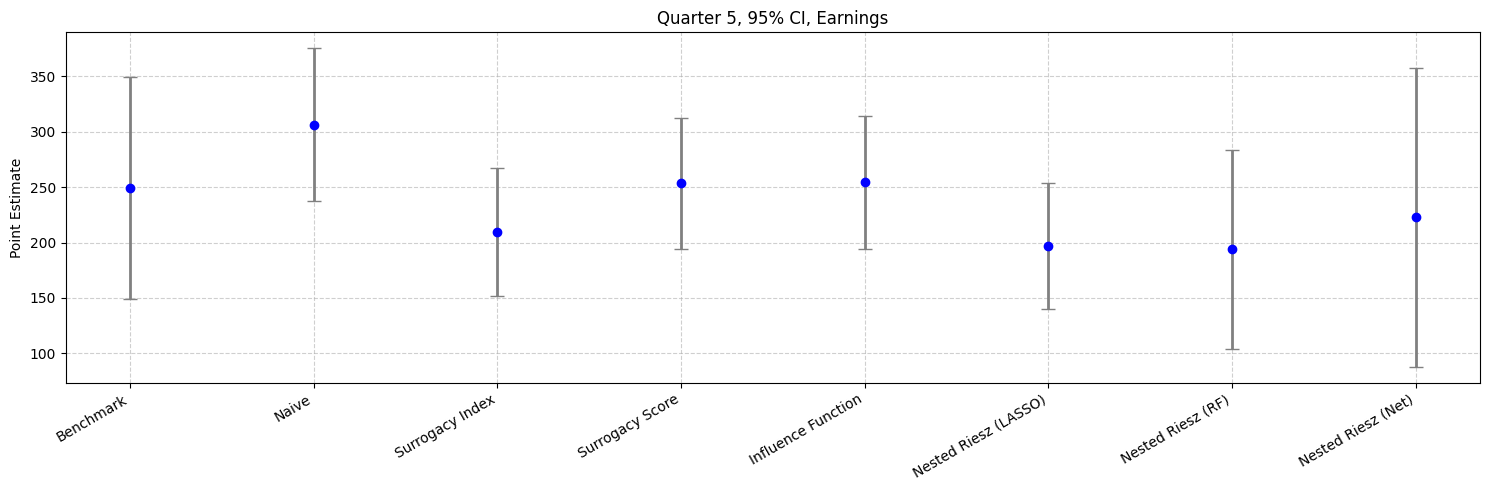

In [12]:
atts_athey_5 = np.array([ 306.5 , 209.6 ,  253.4,  254.4])
stds_athey_5  =np.array( [35.2, 29.5, 30.3,30.7])
robust_bounds = ci(ATT_5, std_5/np.sqrt(n))

plot_estimators(atts_athey_5,stds_athey_5, ATT_5, robust_bounds, "Quarter 5, 95% CI, Earnings",0)

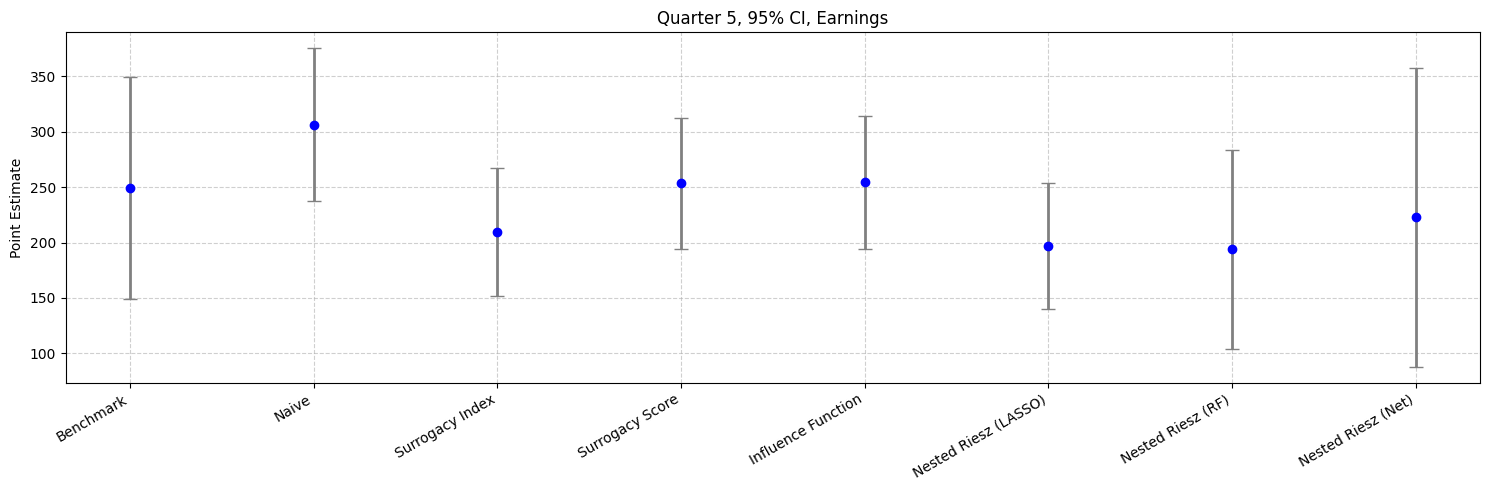

In [ ]:
atts_athey_5 = np.array([ 306.5 , 209.6 ,  253.4,  254.4])
stds_athey_5  =np.array( [35.2, 29.5, 30.3,30.7])
robust_bounds = ci(ATT_5, std_5/np.sqrt(n))

plot_estimators(atts_athey_5,stds_athey_5, ATT_5, robust_bounds, "Quarter 5, 95% CI, Earnings",)

## Employ

In [11]:
import pickle
ds = create_dataset(6, "employ")
Y_exp= ds["Y_experimental"]
D_exp = ds["D_exp"]
true_effect, true_sd  =difference_of_means(Y_exp[D_exp == 1], Y_exp[D_exp ==0])
print(true_effect, f"({true_sd})")
with open("../NNIPV/results_nnpiv.pkl", "rb") as f:
    results = pickle.load(f)

0.06370271132260347 (0.009934125675486934)


In [12]:
estimates = pd.read_csv("application_results_final/employ_q6.csv")
atts_athey_6= np.array([0.117, 0.061,  0.063,   0.065])
stds_athey_6  =np.array( [  0.010,  0.006, 0.006, 0.006])

ATT_6  = [float(re.search(r"tensor\(([-\d\.]+)", s).group(1)) for s in estimates.iloc[:, ::2].values.flatten()]

std_6 = [float(re.search(r"tensor\(([-\d\.]+)", s).group(1)) for s in estimates.iloc[:, 1::2].values.flatten()]

robust_bounds = ci(ATT_6, std_6/np.sqrt(n))


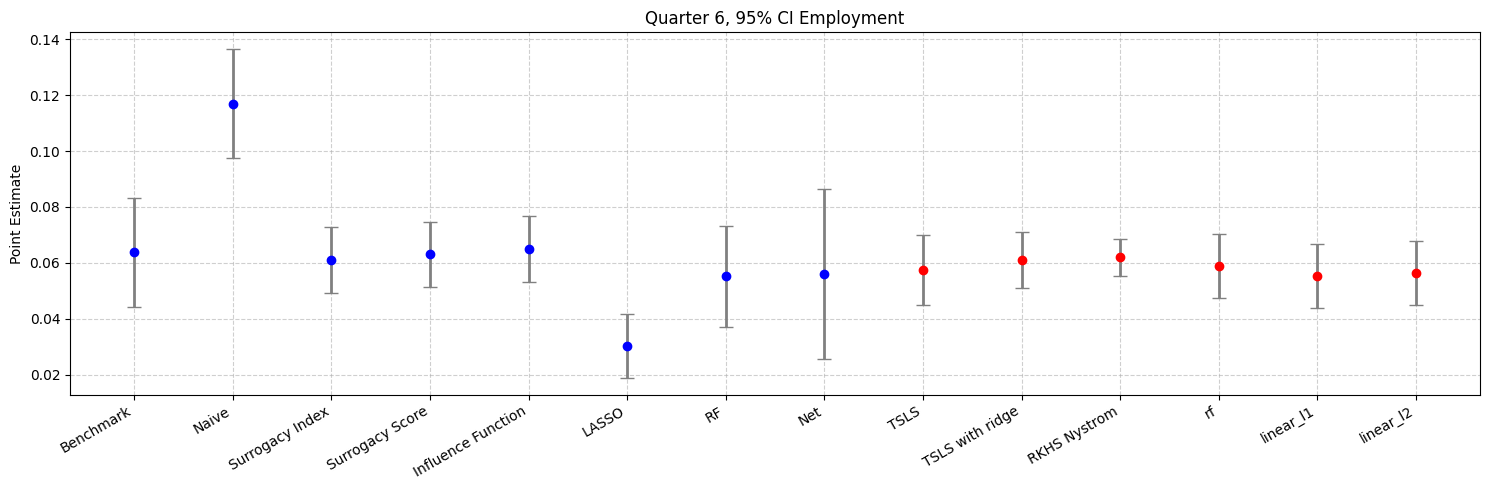

In [13]:
plot_estimators(atts_athey_6,stds_athey_6, ATT_6, robust_bounds, "Quarter 6, 95% CI Employment", exclude_last=1 ,extra_estimators=results)

Final Estimators

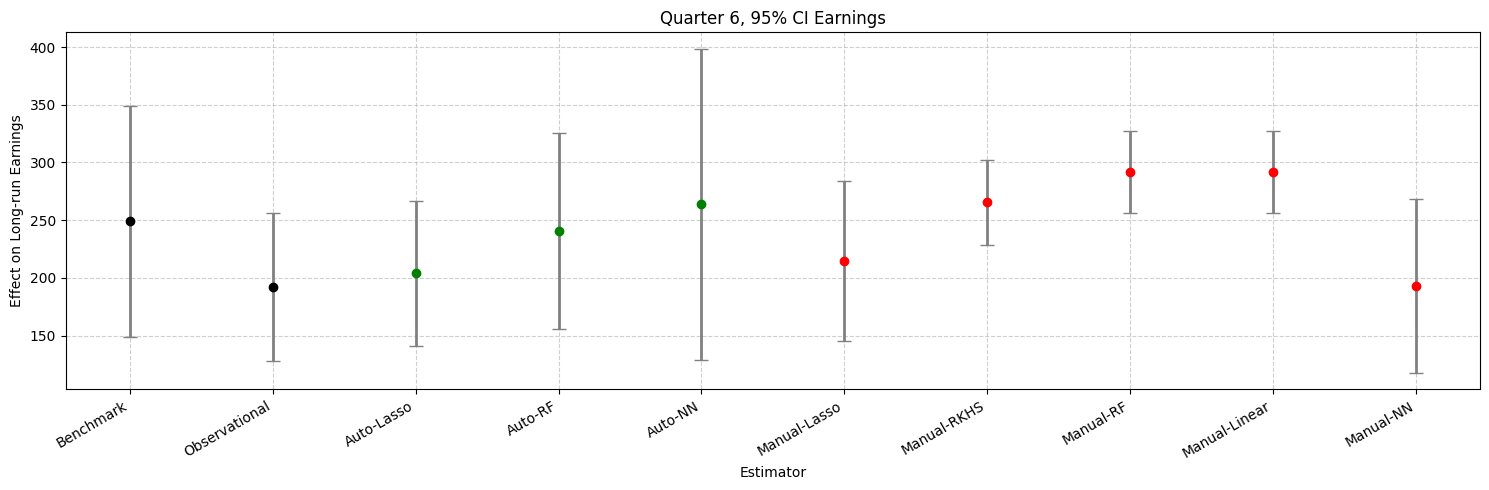

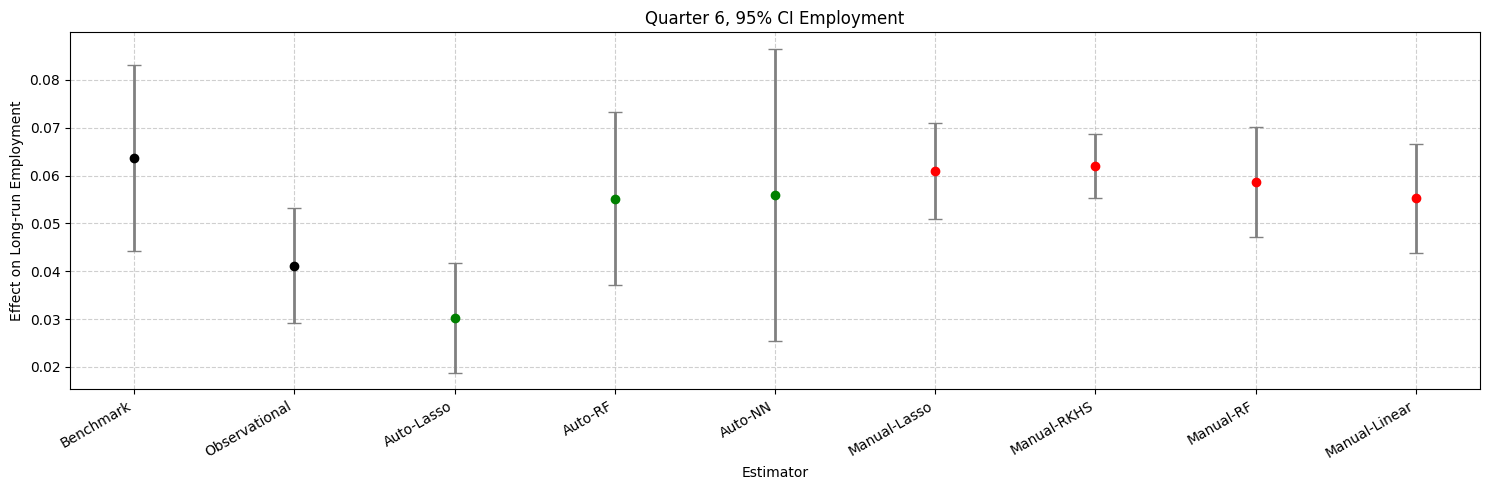

In [18]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------
# Data loading helpers (inlined, self-contained)
# ---------------------------------------------------------------
river_data = pd.read_csv("data/river_data.csv")   # experimental
other_data = pd.read_csv("data/others_data.csv")  # observational

pretreat_vars = (
    [f"paid{i}" for i in range(1, 5)] +
    [f"tcpp{i}" for i in range(1, 11)] +
    [f"tcprn{i}" for i in range(1, 11)]
)
covariates = [
    "xsexf", "xhsdip", "xchld05", "single",
    "grd1720", "grade16", "grd1315", "grade12", "grde911", "white",
    "hisp", "black", "age"
] + pretreat_vars

def create_dataset(quarters, application):
    if application not in ["earn", "employ"]:
        raise ValueError
    Y_observed = other_data[f"Y_{application}"]
    Y_experimental = river_data[f"Y_{application}"]
    if application == "employ":
        s_columns = (
            [f"{application}{i}" for i in range(1, quarters + 1)] +
            [f"aid{i}" for i in range(1, quarters + 1)] +
            [f"earn{i}" for i in range(1, quarters + 1)]
        )
    else:
        s_columns = (
            [f"{application}{i}" for i in range(1, quarters + 1)] +
            [f"aid{i}" for i in range(1, quarters + 1)]
        )
    D_exp = river_data["e"]
    D_obs = other_data["e"]
    return {
        "Y_observed": Y_observed, "Y_experimental": Y_experimental,
        "D_exp": D_exp, "D_obs": D_obs,
        "names_z": s_columns,
        "n_total": len(D_obs) + len(D_exp),
    }

def difference_of_means(treated, control):
    treated = np.asarray(treated)
    control = np.asarray(control)
    n_t, n_c = len(treated), len(control)
    mean_t, mean_c = np.mean(treated), np.mean(control)
    var_t, var_c = np.var(treated), np.var(control)
    diff = mean_t - mean_c
    se = np.sqrt(var_t / n_t + var_c / n_c)
    return diff, se

def ci(estimates, stds, z=1.96):
    estimates = np.asarray(estimates)
    stds = np.asarray(stds)
    return estimates + z * stds, estimates - z * stds

# ---------------------------------------------------------------
# Plotting helper
# ---------------------------------------------------------------
label_map = {
    "linear_l1": "Manual-Linear",
    "RKHS Nystrom": "Manual-RKHS",
    "TSLS with ridge": "Manual-Lasso",
    "rf": "Manual-RF",
    "net": "Manual-NN",
}

def plot_application(true_effect, true_se, obs_effect, obs_se, ATT, std, n,
                      nnpiv_results, caption, ylabel, exclude_last=0):
    ATT = np.asarray(ATT)
    std = np.asarray(std)

    benchmark_bounds = ci(true_effect, true_se)
    observational_bounds = ci(obs_effect, obs_se)
    auto_bounds = ci(ATT, std / np.sqrt(n))

    main_labels = ["Benchmark", "Observational", "Auto-Lasso", "Auto-RF", "Auto-NN"]
    main_colors = ["black", "black", "green", "green", "green"]
    main_estimates = np.concatenate(([true_effect], [obs_effect], ATT))
    main_upper = np.concatenate(([benchmark_bounds[0]], [observational_bounds[0]], auto_bounds[0]))
    main_lower = np.concatenate(([benchmark_bounds[1]], [observational_bounds[1]], auto_bounds[1]))

    manual_results = {label_map[k]: v for k, v in nnpiv_results.items() if k in label_map}
    manual_labels = list(manual_results.keys())
    manual_means = np.array([v[0] for v in manual_results.values()])
    manual_bounds_arr = np.array([v[2] for v in manual_results.values()])
    manual_lower = manual_bounds_arr[:, 0]
    manual_upper = manual_bounds_arr[:, 1]

    if exclude_last > 0:
        manual_labels = manual_labels[:-exclude_last]
        manual_means = manual_means[:-exclude_last]
        manual_lower = manual_lower[:-exclude_last]
        manual_upper = manual_upper[:-exclude_last]

    plt.figure(figsize=(15, 5))
    for i, (label, color) in enumerate(zip(main_labels, main_colors)):
        plt.errorbar(
            x=[label], y=[main_estimates[i]],
            yerr=[[main_estimates[i] - main_lower[i]], [main_upper[i] - main_estimates[i]]],
            fmt='o', capsize=5, color=color, ecolor='gray', elinewidth=2
        )
    plt.errorbar(
        x=manual_labels, y=manual_means,
        yerr=[manual_means - manual_lower, manual_upper - manual_means],
        fmt='o', capsize=5, color='red', ecolor='gray', elinewidth=2
    )
    plt.xlabel('Estimator')
    plt.ylabel(ylabel)
    plt.title(caption)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------------
# Earnings (Quarter 6)
# ---------------------------------------------------------------
ds_earn = create_dataset(6, "earn")
true_effect_earn, true_se_earn = difference_of_means(
    ds_earn["Y_experimental"][ds_earn["D_exp"] == 1],
    ds_earn["Y_experimental"][ds_earn["D_exp"] == 0]
)
obs_effect_earn, obs_se_earn = difference_of_means(
    ds_earn["Y_observed"][ds_earn["D_obs"] == 1],
    ds_earn["Y_observed"][ds_earn["D_obs"] == 0]
)
n = ds_earn["n_total"]

estimates_earn = pd.read_csv("application_results_final/q6.csv")
ATT_6 = [float(re.search(r"tensor\(([-\d\.]+)", s).group(1)) for s in estimates_earn.iloc[:, ::2].values.flatten()]
std_6 = [float(re.search(r"tensor\(([-\d\.]+)", s).group(1)) for s in estimates_earn.iloc[:, 1::2].values.flatten()]

with open("../NNIPV/results_nnpiv_earnings.pkl", "rb") as f:
    results_earn = pickle.load(f)

plot_application(true_effect_earn, true_se_earn, obs_effect_earn, obs_se_earn,
                  ATT_6, std_6, n, results_earn, "Quarter 6, 95% CI Earnings",
                  ylabel="Effect on Long-run Earnings")

# ---------------------------------------------------------------
# Employment (Quarter 6)
# ---------------------------------------------------------------
ds_employ = create_dataset(6, "employ")
true_effect_employ, true_se_employ = difference_of_means(
    ds_employ["Y_experimental"][ds_employ["D_exp"] == 1],
    ds_employ["Y_experimental"][ds_employ["D_exp"] == 0]
)
obs_effect_employ, obs_se_employ = difference_of_means(
    ds_employ["Y_observed"][ds_employ["D_obs"] == 1],
    ds_employ["Y_observed"][ds_employ["D_obs"] == 0]
)

estimates_employ = pd.read_csv("application_results_final/employ_q6.csv")
ATT_6_employ = [float(re.search(r"tensor\(([-\d\.]+)", s).group(1)) for s in estimates_employ.iloc[:, ::2].values.flatten()]
std_6_employ = [float(re.search(r"tensor\(([-\d\.]+)", s).group(1)) for s in estimates_employ.iloc[:, 1::2].values.flatten()]

with open("../NNIPV/results_nnpiv.pkl", "rb") as f:
    results_employ = pickle.load(f)

plot_application(true_effect_employ, true_se_employ, obs_effect_employ, obs_se_employ,
                  ATT_6_employ, std_6_employ, n, results_employ,
                  "Quarter 6, 95% CI Employment", ylabel="Effect on Long-run Employment",
                  exclude_last=1)

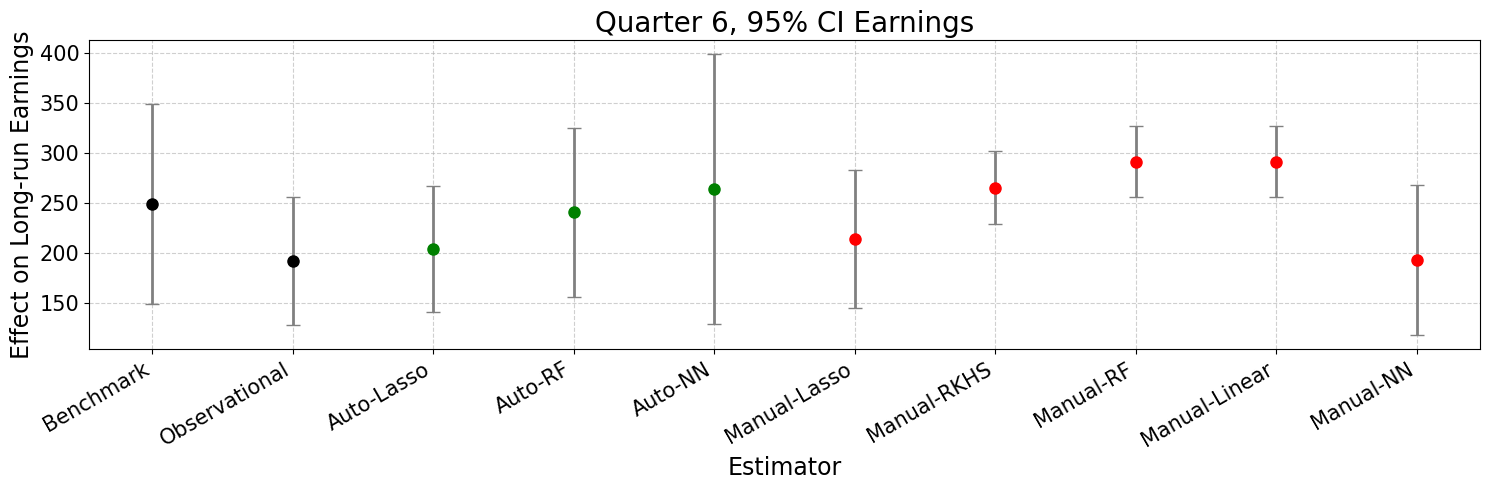

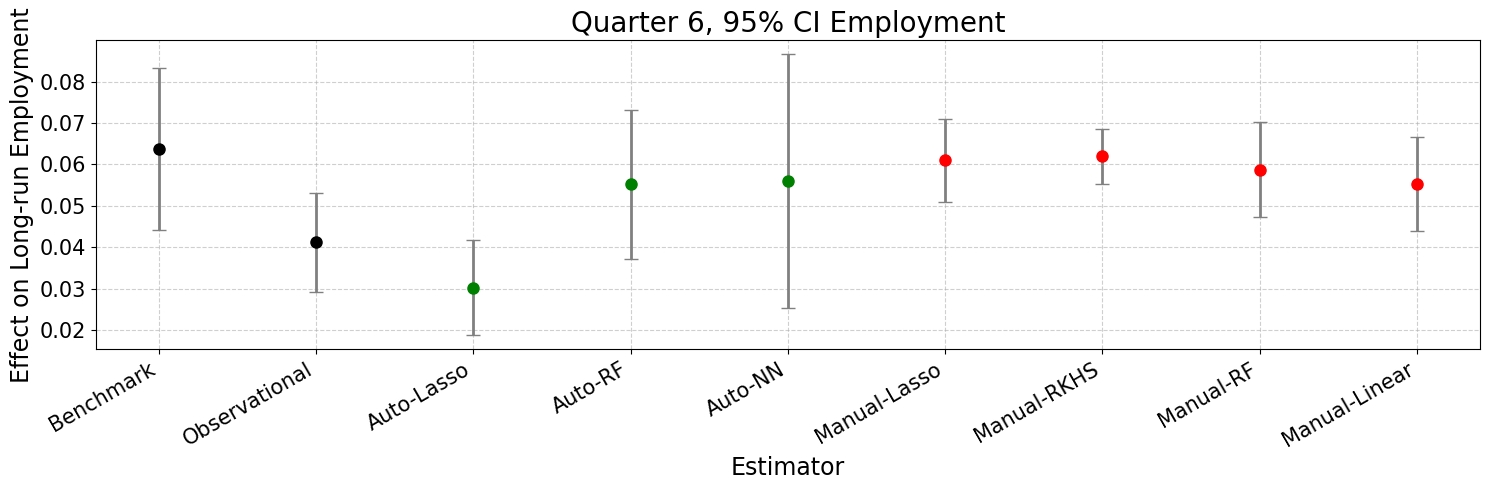

In [20]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------
# Data loading helpers (inlined, self-contained)
# ---------------------------------------------------------------
river_data = pd.read_csv("data/river_data.csv")   # experimental
other_data = pd.read_csv("data/others_data.csv")  # observational

pretreat_vars = (
    [f"paid{i}" for i in range(1, 5)] +
    [f"tcpp{i}" for i in range(1, 11)] +
    [f"tcprn{i}" for i in range(1, 11)]
)
covariates = [
    "xsexf", "xhsdip", "xchld05", "single",
    "grd1720", "grade16", "grd1315", "grade12", "grde911", "white",
    "hisp", "black", "age"
] + pretreat_vars

def create_dataset(quarters, application):
    if application not in ["earn", "employ"]:
        raise ValueError
    Y_observed = other_data[f"Y_{application}"]
    Y_experimental = river_data[f"Y_{application}"]
    if application == "employ":
        s_columns = (
            [f"{application}{i}" for i in range(1, quarters + 1)] +
            [f"aid{i}" for i in range(1, quarters + 1)] +
            [f"earn{i}" for i in range(1, quarters + 1)]
        )
    else:
        s_columns = (
            [f"{application}{i}" for i in range(1, quarters + 1)] +
            [f"aid{i}" for i in range(1, quarters + 1)]
        )
    D_exp = river_data["e"]
    D_obs = other_data["e"]
    return {
        "Y_observed": Y_observed, "Y_experimental": Y_experimental,
        "D_exp": D_exp, "D_obs": D_obs,
        "names_z": s_columns,
        "n_total": len(D_obs) + len(D_exp),
    }

def difference_of_means(treated, control):
    treated = np.asarray(treated)
    control = np.asarray(control)
    n_t, n_c = len(treated), len(control)
    mean_t, mean_c = np.mean(treated), np.mean(control)
    var_t, var_c = np.var(treated), np.var(control)
    diff = mean_t - mean_c
    se = np.sqrt(var_t / n_t + var_c / n_c)
    return diff, se

def ci(estimates, stds, z=1.96):
    estimates = np.asarray(estimates)
    stds = np.asarray(stds)
    return estimates + z * stds, estimates - z * stds

# ---------------------------------------------------------------
# Plotting helper
# ---------------------------------------------------------------
label_map = {
    "linear_l1": "Manual-Linear",
    "RKHS Nystrom": "Manual-RKHS",
    "TSLS with ridge": "Manual-Lasso",
    "rf": "Manual-RF",
    "net": "Manual-NN",
}

# Font-size controls — bump these up for larger paper figures
TITLE_SIZE = 20
AXIS_LABEL_SIZE = 17
TICK_LABEL_SIZE = 15

def plot_application(true_effect, true_se, obs_effect, obs_se, ATT, std, n,
                      nnpiv_results, caption, ylabel, exclude_last=0):
    ATT = np.asarray(ATT)
    std = np.asarray(std)

    benchmark_bounds = ci(true_effect, true_se)
    observational_bounds = ci(obs_effect, obs_se)
    auto_bounds = ci(ATT, std / np.sqrt(n))

    main_labels = ["Benchmark", "Observational", "Auto-Lasso", "Auto-RF", "Auto-NN"]
    main_colors = ["black", "black", "green", "green", "green"]
    main_estimates = np.concatenate(([true_effect], [obs_effect], ATT))
    main_upper = np.concatenate(([benchmark_bounds[0]], [observational_bounds[0]], auto_bounds[0]))
    main_lower = np.concatenate(([benchmark_bounds[1]], [observational_bounds[1]], auto_bounds[1]))

    manual_results = {label_map[k]: v for k, v in nnpiv_results.items() if k in label_map}
    manual_labels = list(manual_results.keys())
    manual_means = np.array([v[0] for v in manual_results.values()])
    manual_bounds_arr = np.array([v[2] for v in manual_results.values()])
    manual_lower = manual_bounds_arr[:, 0]
    manual_upper = manual_bounds_arr[:, 1]

    if exclude_last > 0:
        manual_labels = manual_labels[:-exclude_last]
        manual_means = manual_means[:-exclude_last]
        manual_lower = manual_lower[:-exclude_last]
        manual_upper = manual_upper[:-exclude_last]

    plt.figure(figsize=(15, 5))
    for i, (label, color) in enumerate(zip(main_labels, main_colors)):
        plt.errorbar(
            x=[label], y=[main_estimates[i]],
            yerr=[[main_estimates[i] - main_lower[i]], [main_upper[i] - main_estimates[i]]],
            fmt='o', capsize=5, markersize=8, color=color, ecolor='gray', elinewidth=2
        )
    plt.errorbar(
        x=manual_labels, y=manual_means,
        yerr=[manual_means - manual_lower, manual_upper - manual_means],
        fmt='o', capsize=5, markersize=8, color='red', ecolor='gray', elinewidth=2
    )

    plt.xlabel('Estimator', fontsize=AXIS_LABEL_SIZE)
    plt.ylabel(ylabel, fontsize=AXIS_LABEL_SIZE)
    plt.title(caption, fontsize=TITLE_SIZE)
    plt.xticks(rotation=30, ha='right', fontsize=TICK_LABEL_SIZE)
    plt.yticks(fontsize=TICK_LABEL_SIZE)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------------
# Earnings (Quarter 6)
# ---------------------------------------------------------------
ds_earn = create_dataset(6, "earn")
true_effect_earn, true_se_earn = difference_of_means(
    ds_earn["Y_experimental"][ds_earn["D_exp"] == 1],
    ds_earn["Y_experimental"][ds_earn["D_exp"] == 0]
)
obs_effect_earn, obs_se_earn = difference_of_means(
    ds_earn["Y_observed"][ds_earn["D_obs"] == 1],
    ds_earn["Y_observed"][ds_earn["D_obs"] == 0]
)
n = ds_earn["n_total"]

estimates_earn = pd.read_csv("application_results_final/q6.csv")
ATT_6 = [float(re.search(r"tensor\(([-\d\.]+)", s).group(1)) for s in estimates_earn.iloc[:, ::2].values.flatten()]
std_6 = [float(re.search(r"tensor\(([-\d\.]+)", s).group(1)) for s in estimates_earn.iloc[:, 1::2].values.flatten()]

with open("../NNIPV/results_nnpiv_earnings.pkl", "rb") as f:
    results_earn = pickle.load(f)

plot_application(true_effect_earn, true_se_earn, obs_effect_earn, obs_se_earn,
                  ATT_6, std_6, n, results_earn, "Quarter 6, 95% CI Earnings",
                  ylabel="Effect on Long-run Earnings")

# ---------------------------------------------------------------
# Employment (Quarter 6)
# ---------------------------------------------------------------
ds_employ = create_dataset(6, "employ")
true_effect_employ, true_se_employ = difference_of_means(
    ds_employ["Y_experimental"][ds_employ["D_exp"] == 1],
    ds_employ["Y_experimental"][ds_employ["D_exp"] == 0]
)
obs_effect_employ, obs_se_employ = difference_of_means(
    ds_employ["Y_observed"][ds_employ["D_obs"] == 1],
    ds_employ["Y_observed"][ds_employ["D_obs"] == 0]
)

estimates_employ = pd.read_csv("application_results_final/employ_q6.csv")
ATT_6_employ = [float(re.search(r"tensor\(([-\d\.]+)", s).group(1)) for s in estimates_employ.iloc[:, ::2].values.flatten()]
std_6_employ = [float(re.search(r"tensor\(([-\d\.]+)", s).group(1)) for s in estimates_employ.iloc[:, 1::2].values.flatten()]

with open("../NNIPV/results_nnpiv.pkl", "rb") as f:
    results_employ = pickle.load(f)

plot_application(true_effect_employ, true_se_employ, obs_effect_employ, obs_se_employ,
                  ATT_6_employ, std_6_employ, n, results_employ,
                  "Quarter 6, 95% CI Employment", ylabel="Effect on Long-run Employment",
                  exclude_last=1)

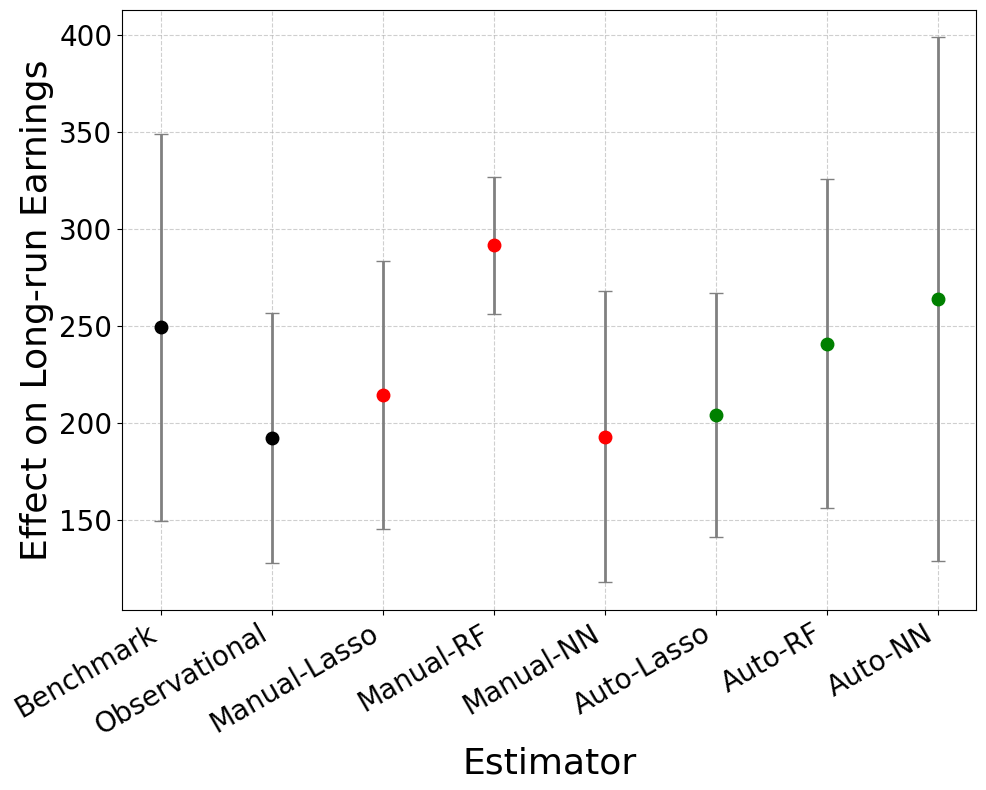

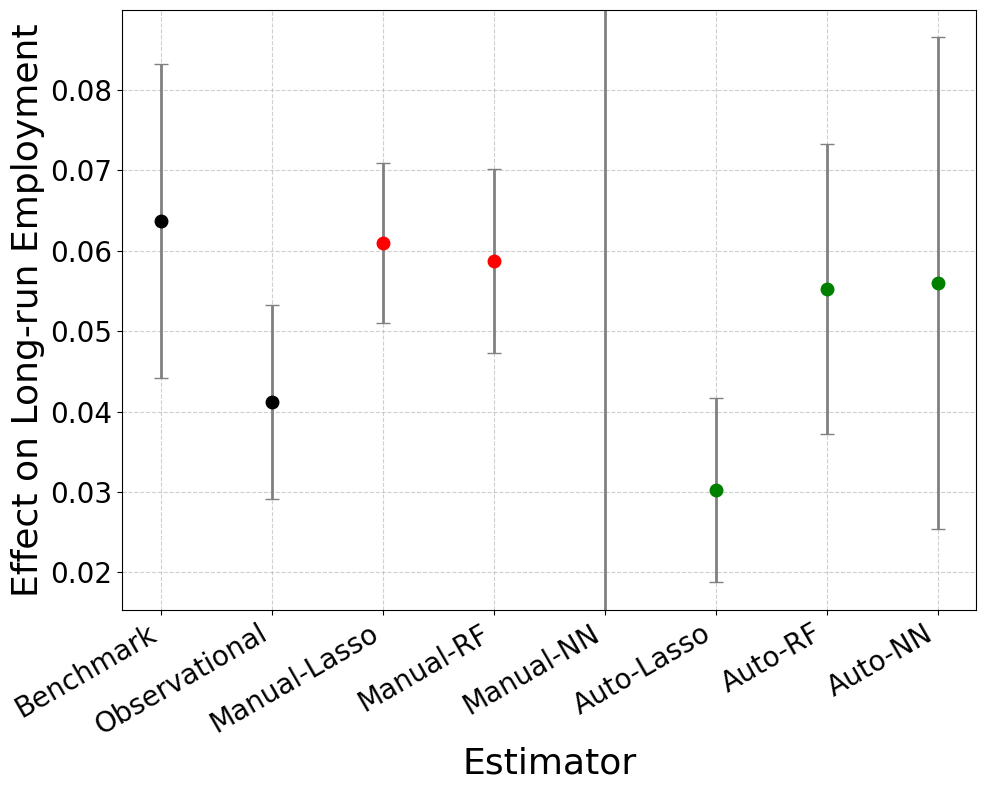

In [1]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------
# Data loading helpers (inlined, self-contained)
# ---------------------------------------------------------------
river_data = pd.read_csv("data/river_data.csv")   # experimental
other_data = pd.read_csv("data/others_data.csv")  # observational

pretreat_vars = (
    [f"paid{i}" for i in range(1, 5)] +
    [f"tcpp{i}" for i in range(1, 11)] +
    [f"tcprn{i}" for i in range(1, 11)]
)
covariates = [
    "xsexf", "xhsdip", "xchld05", "single",
    "grd1720", "grade16", "grd1315", "grade12", "grde911", "white",
    "hisp", "black", "age"
] + pretreat_vars

def create_dataset(quarters, application):
    if application not in ["earn", "employ"]:
        raise ValueError
    Y_observed = other_data[f"Y_{application}"]
    Y_experimental = river_data[f"Y_{application}"]
    if application == "employ":
        s_columns = (
            [f"{application}{i}" for i in range(1, quarters + 1)] +
            [f"aid{i}" for i in range(1, quarters + 1)] +
            [f"earn{i}" for i in range(1, quarters + 1)]
        )
    else:
        s_columns = (
            [f"{application}{i}" for i in range(1, quarters + 1)] +
            [f"aid{i}" for i in range(1, quarters + 1)]
        )
    D_exp = river_data["e"]
    D_obs = other_data["e"]
    return {
        "Y_observed": Y_observed, "Y_experimental": Y_experimental,
        "D_exp": D_exp, "D_obs": D_obs,
        "names_z": s_columns,
        "n_total": len(D_obs) + len(D_exp),
    }

def difference_of_means(treated, control):
    treated = np.asarray(treated)
    control = np.asarray(control)
    n_t, n_c = len(treated), len(control)
    mean_t, mean_c = np.mean(treated), np.mean(control)
    var_t, var_c = np.var(treated), np.var(control)
    diff = mean_t - mean_c
    se = np.sqrt(var_t / n_t + var_c / n_c)
    return diff, se

def ci(estimates, stds, z=1.96):
    estimates = np.asarray(estimates)
    stds = np.asarray(stds)
    return estimates + z * stds, estimates - z * stds

# ---------------------------------------------------------------
# Plotting helper
# ---------------------------------------------------------------
# Only Manual-Lasso, Manual-RF, Manual-NN are kept from nnpiv_results
# (Manual-Linear and Manual-RKHS are dropped).
label_map = {
    "TSLS with ridge": "Manual-Lasso",
    "rf": "Manual-RF",
    "net": "Manual-NN",
}
MANUAL_ORDER = ["Manual-Lasso", "Manual-RF", "Manual-NN"]

# Font-size controls — bumped up for legibility inside a 1x2 figure grid
AXIS_LABEL_SIZE = 26
TICK_LABEL_SIZE = 20

# Colors: Benchmark/Observational black, Manual-* red, Auto-* (ours) green
COLOR_BASELINE = "black"
COLOR_MANUAL = "red"
COLOR_AUTO = "green"


def plot_application(true_effect, true_se, obs_effect, obs_se, ATT, std, n,
                      nnpiv_results, ylabel, exclude_manual_nn_from_scale=False):
    """
    Plots: Benchmark, Observational (black) -> Manual-Lasso, Manual-RF, Manual-NN (red)
           -> Auto-Lasso, Auto-RF, Auto-NN (green).

    If exclude_manual_nn_from_scale=True, Manual-NN is still plotted (with its full
    error bar), but the y-axis limits are computed ignoring its CI, so one noisy
    estimator doesn't compress the visible scale for everyone else. Its error bar
    will simply extend beyond the visible plot area.
    """
    ATT = np.asarray(ATT)
    std = np.asarray(std)

    benchmark_bounds = ci(true_effect, true_se)
    observational_bounds = ci(obs_effect, obs_se)
    auto_bounds = ci(ATT, std / np.sqrt(n))

    baseline_labels = ["Benchmark", "Observational"]
    baseline_estimates = np.array([true_effect, obs_effect])
    baseline_lower = np.array([benchmark_bounds[1], observational_bounds[1]])
    baseline_upper = np.array([benchmark_bounds[0], observational_bounds[0]])

    auto_labels = ["Auto-Lasso", "Auto-RF", "Auto-NN"]
    auto_estimates = ATT
    auto_lower = auto_bounds[1]
    auto_upper = auto_bounds[0]

    manual_results = {label_map[k]: v for k, v in nnpiv_results.items() if k in label_map}
    manual_means = np.array([manual_results[name][0] for name in MANUAL_ORDER])
    manual_bounds_arr = np.array([manual_results[name][2] for name in MANUAL_ORDER])
    manual_lower = manual_bounds_arr[:, 0]
    manual_upper = manual_bounds_arr[:, 1]
    manual_labels = MANUAL_ORDER

    fig, ax = plt.subplots(figsize=(10, 8))

    # Baseline (black): Benchmark, Observational
    for i, label in enumerate(baseline_labels):
        ax.errorbar(
            x=[label], y=[baseline_estimates[i]],
            yerr=[[baseline_estimates[i] - baseline_lower[i]], [baseline_upper[i] - baseline_estimates[i]]],
            fmt='o', capsize=5, markersize=9, color=COLOR_BASELINE, ecolor='gray', elinewidth=2
        )

    # Manual (red): Manual-Lasso, Manual-RF, Manual-NN
    ax.errorbar(
        x=manual_labels, y=manual_means,
        yerr=[manual_means - manual_lower, manual_upper - manual_means],
        fmt='o', capsize=5, markersize=9, color=COLOR_MANUAL, ecolor='gray', elinewidth=2
    )

    # Auto (green): Auto-Lasso, Auto-RF, Auto-NN
    ax.errorbar(
        x=auto_labels, y=auto_estimates,
        yerr=[auto_estimates - auto_lower, auto_upper - auto_estimates],
        fmt='o', capsize=5, markersize=9, color=COLOR_AUTO, ecolor='gray', elinewidth=2
    )

    ax.set_xlabel('Estimator', fontsize=AXIS_LABEL_SIZE)
    ax.set_ylabel(ylabel, fontsize=AXIS_LABEL_SIZE)
    ax.tick_params(axis='x', labelsize=TICK_LABEL_SIZE, rotation=30)
    ax.tick_params(axis='y', labelsize=TICK_LABEL_SIZE)
    plt.setp(ax.get_xticklabels(), ha='right')
    ax.grid(True, linestyle='--', alpha=0.6)

    # --- Y-axis scaling ---
    # By default, scale to fit every plotted point/CI. If exclude_manual_nn_from_scale
    # is set, compute the scale from everything EXCEPT Manual-NN, while still drawing
    # Manual-NN's (possibly much wider) error bar -- it will extend past the frame.
    if exclude_manual_nn_from_scale:
        scale_lower = np.concatenate((
            baseline_lower, auto_lower,
            manual_lower[np.array(manual_labels) != "Manual-NN"]
        ))
        scale_upper = np.concatenate((
            baseline_upper, auto_upper,
            manual_upper[np.array(manual_labels) != "Manual-NN"]
        ))
    else:
        scale_lower = np.concatenate((baseline_lower, auto_lower, manual_lower))
        scale_upper = np.concatenate((baseline_upper, auto_upper, manual_upper))

    pad = 0.05 * (scale_upper.max() - scale_lower.min())
    ax.set_ylim(scale_lower.min() - pad, scale_upper.max() + pad)

    fig.tight_layout()
    plt.show()


# ---------------------------------------------------------------
# Earnings (Quarter 6)
# ---------------------------------------------------------------
ds_earn = create_dataset(6, "earn")
true_effect_earn, true_se_earn = difference_of_means(
    ds_earn["Y_experimental"][ds_earn["D_exp"] == 1],
    ds_earn["Y_experimental"][ds_earn["D_exp"] == 0]
)
obs_effect_earn, obs_se_earn = difference_of_means(
    ds_earn["Y_observed"][ds_earn["D_obs"] == 1],
    ds_earn["Y_observed"][ds_earn["D_obs"] == 0]
)
n = ds_earn["n_total"]

estimates_earn = pd.read_csv("application_results_final/q6.csv")
ATT_6 = [float(re.search(r"tensor\(([-\d\.]+)", s).group(1)) for s in estimates_earn.iloc[:, ::2].values.flatten()]
std_6 = [float(re.search(r"tensor\(([-\d\.]+)", s).group(1)) for s in estimates_earn.iloc[:, 1::2].values.flatten()]

with open("../NNIPV/results_nnpiv_earnings.pkl", "rb") as f:
    results_earn = pickle.load(f)

plot_application(true_effect_earn, true_se_earn, obs_effect_earn, obs_se_earn,
                  ATT_6, std_6, n, results_earn,
                  ylabel="Effect on Long-run Earnings")

# ---------------------------------------------------------------
# Employment (Quarter 6)
# ---------------------------------------------------------------
ds_employ = create_dataset(6, "employ")
true_effect_employ, true_se_employ = difference_of_means(
    ds_employ["Y_experimental"][ds_employ["D_exp"] == 1],
    ds_employ["Y_experimental"][ds_employ["D_exp"] == 0]
)
obs_effect_employ, obs_se_employ = difference_of_means(
    ds_employ["Y_observed"][ds_employ["D_obs"] == 1],
    ds_employ["Y_observed"][ds_employ["D_obs"] == 0]
)

estimates_employ = pd.read_csv("application_results_final/employ_q6.csv")
ATT_6_employ = [float(re.search(r"tensor\(([-\d\.]+)", s).group(1)) for s in estimates_employ.iloc[:, ::2].values.flatten()]
std_6_employ = [float(re.search(r"tensor\(([-\d\.]+)", s).group(1)) for s in estimates_employ.iloc[:, 1::2].values.flatten()]

with open("../NNIPV/results_nnpiv.pkl", "rb") as f:
    results_employ = pickle.load(f)

plot_application(true_effect_employ, true_se_employ, obs_effect_employ, obs_se_employ,
                  ATT_6_employ, std_6_employ, n, results_employ,
                  ylabel="Effect on Long-run Employment",
                  exclude_manual_nn_from_scale=True)

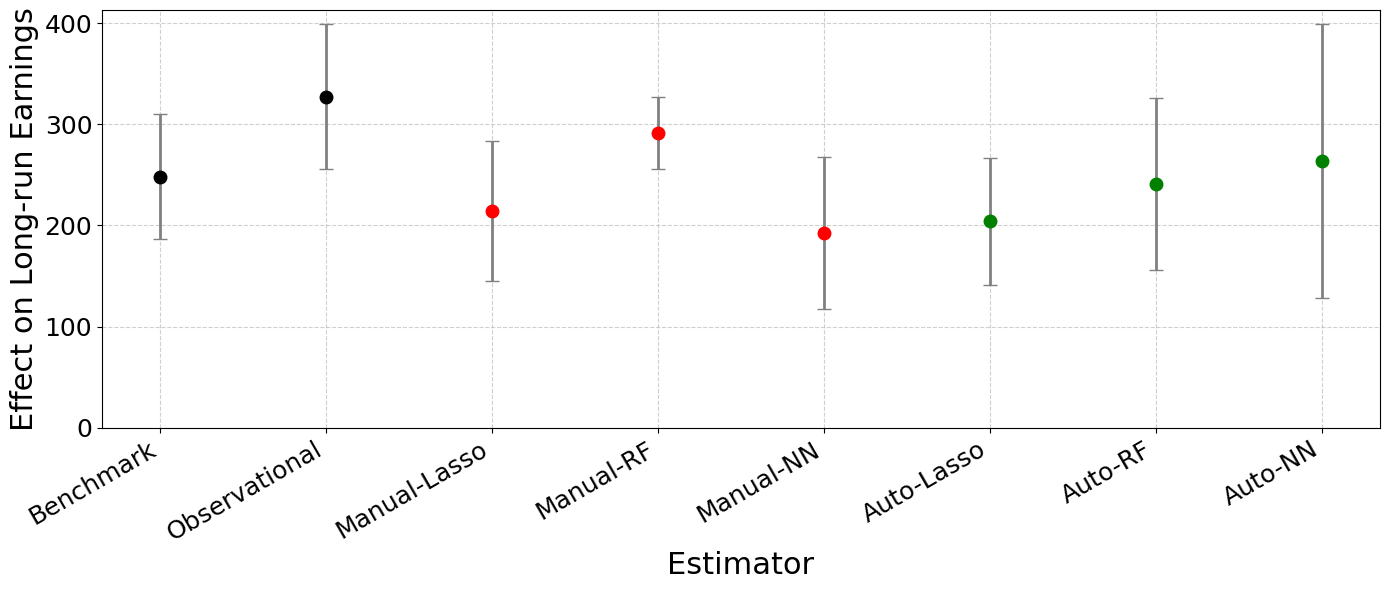

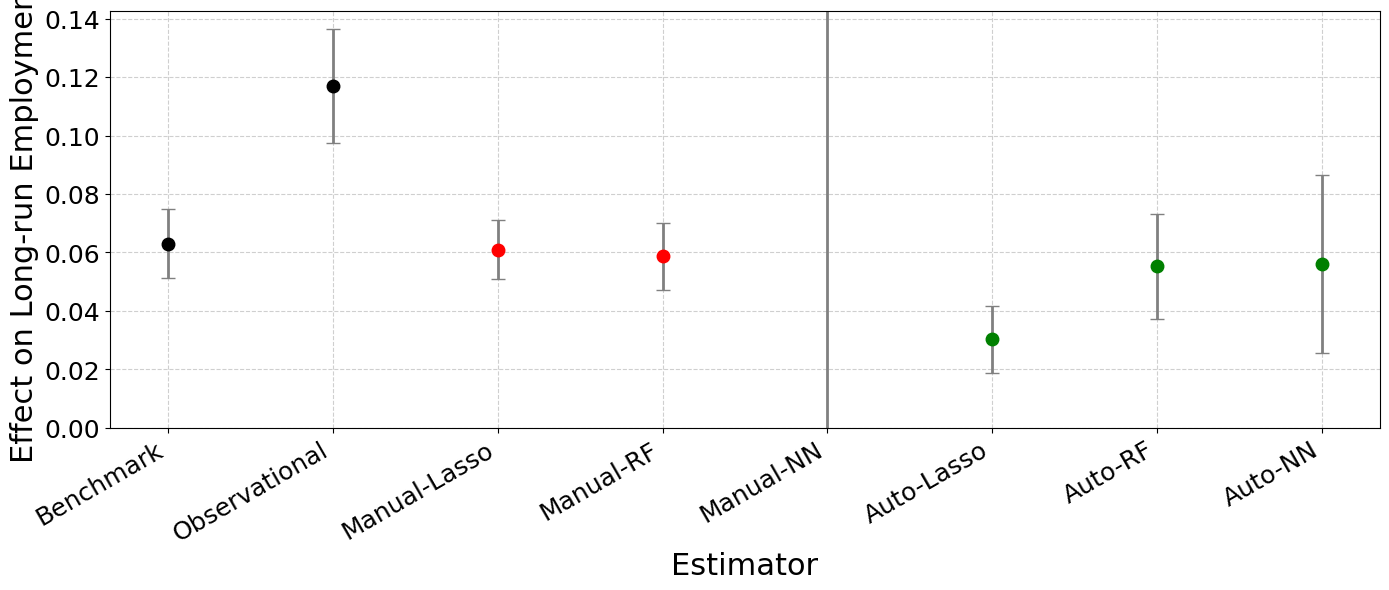

In [12]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------
# Data loading helpers (inlined, self-contained)
# ---------------------------------------------------------------
river_data = pd.read_csv("data/river_data.csv")   # experimental
other_data = pd.read_csv("data/others_data.csv")  # observational

pretreat_vars = (
    [f"paid{i}" for i in range(1, 5)] +
    [f"tcpp{i}" for i in range(1, 11)] +
    [f"tcprn{i}" for i in range(1, 11)]
)
covariates = [
    "xsexf", "xhsdip", "xchld05", "single",
    "grd1720", "grade16", "grd1315", "grade12", "grde911", "white",
    "hisp", "black", "age"
] + pretreat_vars

def create_dataset(quarters, application):
    if application not in ["earn", "employ"]:
        raise ValueError
    Y_observed = other_data[f"Y_{application}"]
    Y_experimental = river_data[f"Y_{application}"]
    if application == "employ":
        s_columns = (
            [f"{application}{i}" for i in range(1, quarters + 1)] +
            [f"aid{i}" for i in range(1, quarters + 1)] +
            [f"earn{i}" for i in range(1, quarters + 1)]
        )
    else:
        s_columns = (
            [f"{application}{i}" for i in range(1, quarters + 1)] +
            [f"aid{i}" for i in range(1, quarters + 1)]
        )
    D_exp = river_data["e"]
    D_obs = other_data["e"]
    return {
        "Y_observed": Y_observed, "Y_experimental": Y_experimental,
        "D_exp": D_exp, "D_obs": D_obs,
        "names_z": s_columns,
        "n_total": len(D_obs) + len(D_exp),
    }

def difference_of_means(treated, control):
    treated = np.asarray(treated)
    control = np.asarray(control)
    n_t, n_c = len(treated), len(control)
    mean_t, mean_c = np.mean(treated), np.mean(control)
    var_t, var_c = np.var(treated), np.var(control)
    diff = mean_t - mean_c
    se = np.sqrt(var_t / n_t + var_c / n_c)
    return diff, se

def ci(estimates, stds, z=1.96):
    estimates = np.asarray(estimates)
    stds = np.asarray(stds)
    return estimates + z * stds, estimates - z * stds

# ---------------------------------------------------------------
# Plotting helper
# ---------------------------------------------------------------
# Only Manual-Lasso, Manual-RF, Manual-NN are kept from nnpiv_results
# (Manual-Linear and Manual-RKHS are dropped).
label_map = {
    "TSLS with ridge": "Manual-Lasso",
    "rf": "Manual-RF",
    "net": "Manual-NN",
}
MANUAL_ORDER = ["Manual-Lasso", "Manual-RF", "Manual-NN"]

# Font-size controls — sized for figures stacked vertically in the paper
AXIS_LABEL_SIZE = 22
TICK_LABEL_SIZE = 18

# Colors: Benchmark/Observational black, Manual-* red, Auto-* (ours) green
COLOR_BASELINE = "black"
COLOR_MANUAL = "red"
COLOR_AUTO = "green"


def plot_application(true_effect, true_se, obs_effect, obs_se, ATT, std, n,
                      nnpiv_results, ylabel, exclude_manual_nn_from_scale=False):
    """
    Plots: Benchmark, Observational (black) -> Manual-Lasso, Manual-RF, Manual-NN (red)
           -> Auto-Lasso, Auto-RF, Auto-NN (green).

    Note: obs_effect/obs_se are the hardcoded "Naive" observational-sample estimate
    from Athey et al.'s replication output (327.1 / 0.117), NOT recomputed here -- just
    relabeled "Observational". The benchmark is the experimental difference-in-means.

    If exclude_manual_nn_from_scale=True, Manual-NN is still plotted (with its full
    error bar), but the y-axis limits are computed ignoring its CI, so one noisy
    estimator doesn't compress the visible scale for everyone else. Its error bar
    will simply extend beyond the visible plot area.
    """
    ATT = np.asarray(ATT)
    std = np.asarray(std)

    benchmark_bounds = ci(true_effect, true_se)
    observational_bounds = ci(obs_effect, obs_se)
    auto_bounds = ci(ATT, std / np.sqrt(n))

    baseline_labels = ["Benchmark", "Observational"]
    baseline_estimates = np.array([true_effect, obs_effect])
    baseline_lower = np.array([benchmark_bounds[1], observational_bounds[1]])
    baseline_upper = np.array([benchmark_bounds[0], observational_bounds[0]])

    auto_labels = ["Auto-Lasso", "Auto-RF", "Auto-NN"]
    auto_estimates = ATT
    auto_lower = auto_bounds[1]
    auto_upper = auto_bounds[0]

    manual_results = {label_map[k]: v for k, v in nnpiv_results.items() if k in label_map}
    manual_means = np.array([manual_results[name][0] for name in MANUAL_ORDER])
    manual_bounds_arr = np.array([manual_results[name][2] for name in MANUAL_ORDER])
    manual_lower = manual_bounds_arr[:, 0]
    manual_upper = manual_bounds_arr[:, 1]
    manual_labels = MANUAL_ORDER

    fig, ax = plt.subplots(figsize=(14, 6))

    # Baseline (black): Benchmark, Observational
    for i, label in enumerate(baseline_labels):
        ax.errorbar(
            x=[label], y=[baseline_estimates[i]],
            yerr=[[baseline_estimates[i] - baseline_lower[i]], [baseline_upper[i] - baseline_estimates[i]]],
            fmt='o', capsize=5, markersize=9, color=COLOR_BASELINE, ecolor='gray', elinewidth=2
        )

    # Manual (red): Manual-Lasso, Manual-RF, Manual-NN
    ax.errorbar(
        x=manual_labels, y=manual_means,
        yerr=[manual_means - manual_lower, manual_upper - manual_means],
        fmt='o', capsize=5, markersize=9, color=COLOR_MANUAL, ecolor='gray', elinewidth=2
    )

    # Auto (green): Auto-Lasso, Auto-RF, Auto-NN
    ax.errorbar(
        x=auto_labels, y=auto_estimates,
        yerr=[auto_estimates - auto_lower, auto_upper - auto_estimates],
        fmt='o', capsize=5, markersize=9, color=COLOR_AUTO, ecolor='gray', elinewidth=2
    )

    ax.set_xlabel('Estimator', fontsize=AXIS_LABEL_SIZE)
    ax.set_ylabel(ylabel, fontsize=AXIS_LABEL_SIZE)
    ax.tick_params(axis='x', labelsize=TICK_LABEL_SIZE, rotation=30)
    ax.tick_params(axis='y', labelsize=TICK_LABEL_SIZE)
    plt.setp(ax.get_xticklabels(), ha='right')
    ax.grid(True, linestyle='--', alpha=0.6)

    # --- Y-axis scaling ---
    # By default, scale to fit every plotted point/CI. If exclude_manual_nn_from_scale
    # is set, compute the scale from everything EXCEPT Manual-NN, while still drawing
    # Manual-NN's (possibly much wider) error bar -- it will extend past the frame.
    if exclude_manual_nn_from_scale:
        scale_lower = np.concatenate((
            baseline_lower, auto_lower,
            manual_lower[np.array(manual_labels) != "Manual-NN"]
        ))
        scale_upper = np.concatenate((
            baseline_upper, auto_upper,
            manual_upper[np.array(manual_labels) != "Manual-NN"]
        ))
    else:
        scale_lower = np.concatenate((baseline_lower, auto_lower, manual_lower))
        scale_upper = np.concatenate((baseline_upper, auto_upper, manual_upper))

    pad = 0.05 * (scale_upper.max() - scale_lower.min())
    ax.set_ylim(0, scale_upper.max() + pad)

    fig.tight_layout()
    plt.show()


# ---------------------------------------------------------------
# Earnings (Quarter 6)
# ---------------------------------------------------------------
ds_earn = create_dataset(6, "earn")
# Benchmark = experimental difference-in-means, hardcoded to Athey et al.'s reported value.
true_effect_earn, true_se_earn = 248.0, 31.5
# Observational = Athey et al.'s hardcoded "Naive" estimate (was atts_athey_6[0]),
# relabeled "Observational" -- NOT recomputed.
obs_effect_earn, obs_se_earn = 327.1, 36.6
n = ds_earn["n_total"]

estimates_earn = pd.read_csv("application_results_final/q6.csv")
ATT_6 = [float(re.search(r"tensor\(([-\d\.]+)", s).group(1)) for s in estimates_earn.iloc[:, ::2].values.flatten()]
std_6 = [float(re.search(r"tensor\(([-\d\.]+)", s).group(1)) for s in estimates_earn.iloc[:, 1::2].values.flatten()]

with open("../NNIPV/results_nnpiv_earnings.pkl", "rb") as f:
    results_earn = pickle.load(f)

plot_application(true_effect_earn, true_se_earn, obs_effect_earn, obs_se_earn,
                  ATT_6, std_6, n, results_earn,
                  ylabel="Effect on Long-run Earnings")

# ---------------------------------------------------------------
# Employment (Quarter 6)
# ---------------------------------------------------------------
ds_employ = create_dataset(6, "employ")
# Benchmark = experimental difference-in-means, hardcoded to Athey et al.'s reported value.
true_effect_employ, true_se_employ = 0.063, 0.006
# Observational = Athey et al.'s hardcoded "Naive" estimate (was atts_athey_6[0]),
# relabeled "Observational" -- NOT recomputed.
obs_effect_employ, obs_se_employ = 0.117, 0.010

estimates_employ = pd.read_csv("application_results_final/employ_q6.csv")
ATT_6_employ = [float(re.search(r"tensor\(([-\d\.]+)", s).group(1)) for s in estimates_employ.iloc[:, ::2].values.flatten()]
std_6_employ = [float(re.search(r"tensor\(([-\d\.]+)", s).group(1)) for s in estimates_employ.iloc[:, 1::2].values.flatten()]

with open("../NNIPV/results_nnpiv.pkl", "rb") as f:
    results_employ = pickle.load(f)

plot_application(true_effect_employ, true_se_employ, obs_effect_employ, obs_se_employ,
                  ATT_6_employ, std_6_employ, n, results_employ,
                  ylabel="Effect on Long-run Employment",
                  exclude_manual_nn_from_scale=True)

In [8]:
print("Manual-NN (employ):", results_employ["net"])

Manual-NN (employ): (-0.3072618416345775, 6209.83415505736, array([-1.42278101,  0.80825732]))


In [13]:
# How big is Manual-NN's CI vs the others?
for k in ["TSLS with ridge", "rf", "net"]:
    mean = results_employ[k][0]
    lo, hi = results_employ[k][2]
    print(f"{label_map[k]:12s} mean={mean:8.4f}  CI=[{lo:8.4f}, {hi:8.4f}]  width={hi-lo:8.4f}")
    

Manual-Lasso mean=  0.0610  CI=[  0.0510,   0.0709]  width=  0.0199
Manual-RF    mean=  0.0587  CI=[  0.0472,   0.0701]  width=  0.0229
Manual-NN    mean= -0.3073  CI=[ -1.4228,   0.8083]  width=  2.2310


In [17]:
import pickle
with open("../NNIPV/results_nnpiv.pkl", "rb") as f:
    results = pickle.load(f)

print(type(results))
print("keys:", list(results.keys()))
print("\nnet entry type:", type(results["net"]))
print("net entry:", results["net"])
print("net length:", len(results["net"]))
# inspect each element of the tuple
for i, x in enumerate(results["net"]):

    print(f"  [{i}] type={type(x)}  value={repr(x) if not hasattr(x, 'shape') else f'array shape {x.shape}'}")
    




<class 'dict'>
keys: ['TSLS', 'TSLS with ridge', 'RKHS Nystrom', 'rf', 'linear_l1', 'linear_l2', 'net']

net entry type: <class 'tuple'>
net entry: (-0.3072618416345775, 6209.83415505736, array([-1.42278101,  0.80825732]))
net length: 3
  [0] type=<class 'numpy.float64'>  value=array shape ()
  [1] type=<class 'numpy.float64'>  value=array shape ()
  [2] type=<class 'numpy.ndarray'>  value=array shape (2,)
